In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [27]:
def load_synaptic_weights(filepath: str) -> dict:
    """
    Reads a .dat file containing synaptic weights and organizes them into a dictionary.
    
    Args:
        filepath (str): The path to the file to be read (e.g., 'weights_6000.0.dat').
        
    Returns:
        dict: A dictionary where the keys are the connection names 
              (e.g., 'weights_selective_pop0_to_selective_pop1') and the values 
              are numpy arrays containing the weights (float).
    """
    weights_dict = {}
    current_connection = None

    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            
            if not line:
                continue

            if line.startswith("weights_"):
                current_connection = line
                weights_dict[current_connection] = []
            
            elif current_connection is not None:
                pesi = [float(x) for x in line.split()]
                weights_dict[current_connection].extend(pesi)

    for connection in weights_dict:
        weights_dict[connection] = np.array(weights_dict[connection])

    return weights_dict

In [28]:
data_path = os.path.join(os.getcwd(), "data_mu05_alpha01/weights_15000.0.dat")

weights = load_synaptic_weights(data_path)

In [29]:
all_weights = []
for weights in weights.values():
    all_weights.extend(weights)


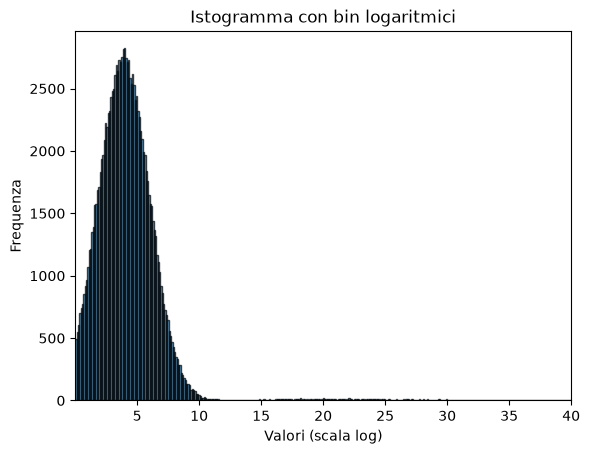

In [30]:
# 1. Definiamo i bin logaritmici (dal minimo al massimo dei dati)
min_val = np.min(all_weights)
max_val = np.max(all_weights)
bins = np.geomspace(min_val, max_val, 100)

# 2. Creiamo l'istogramma
plt.hist(all_weights, bins="auto", edgecolor='black', alpha=0.7)

# 3. Impostiamo l'asse X in scala logaritmica
#plt.xscale('log')
plt.xlim(min_val, 40)

plt.xlabel('Valori (scala log)')
plt.ylabel('Frequenza')
plt.title('Istogramma con bin logaritmici')
plt.show()